# Lab 7- Data Analysis

In this lab, you download and begin to look at a particle physics dataset. You must download the dataset by March 17th and come to class . Exercises 1-4 are to be completed by March 21th. The remaider of the lab is due March 29th. Before leaving lab today, everyone must download the dataset.

## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [5]:
!wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz

--2025-03-20 17:12:42--  http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘SUSY.csv.gz’

SUSY.csv.gz             [      <=>           ] 879.65M  1.19MB/s    in 16m 34s 

2025-03-20 17:29:17 (906 KB/s) - ‘SUSY.csv.gz’ saved [922377711]



In [1]:
!rm SUSY.csv.gz

In [2]:
!gunzip SUSY.csv.gz

gzip: SUSY.csv.gz: No such file or directory


In [3]:
ls -lh

total 2.3G
-rw-r--r-- 1 brianbv brianbv 390K Mar 20 17:35 Lab.7.ipynb
-rw-r--r-- 1 brianbv brianbv 5.9M Mar  7 13:37 Lab.7.pdf
-rw-r--r-- 1 brianbv brianbv 2.3G Mar 20 17:10 SUSY.csv


The data is provided as a comma separated file.

In [3]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [4]:
!ls -lh

total 2.5G
-rw-r--r-- 1 brianbv brianbv 391K Mar 23 19:48 Lab.7.ipynb
-rw-r--r-- 1 brianbv brianbv 5.9M Mar  7 13:37 Lab.7.pdf
-rw-r--r-- 1 brianbv brianbv 228M Mar 20 18:57 SUSY-small.csv
-rw-r--r-- 1 brianbv brianbv 2.3G Mar 20 17:10 SUSY.csv


We see that we have 5 million datapoints.

In [5]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [22]:
!head -500000 SUSY.csv > SUSY-small.csv

In [23]:
ls -lh

total 2.5G
-rw-r--r-- 1 brianbv brianbv 3.3M Mar 28 19:43 Lab.7.ipynb
-rw-r--r-- 1 brianbv brianbv 5.9M Mar  7 13:37 Lab.7.pdf
-rw-r--r-- 1 brianbv brianbv 228M Mar 28 19:45 SUSY-small.csv
-rw-r--r-- 1 brianbv brianbv 2.3G Mar 20 17:10 SUSY.csv


In [24]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [25]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [26]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [27]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [28]:
FeatureNames

['dPhi_r_b',
 'axial_MET',
 'M_Delta_R',
 'M_TR_2',
 'MET_rel',
 'MT2',
 'cos_theta_r1',
 'M_R',
 'R',
 'S_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [30]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [31]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


In [32]:
df.columns

Index(['signal', 'l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta',
       'l_2_phi', 'MET', 'MET_phi', 'MET_rel', 'axial_MET', 'M_R', 'M_TR_2',
       'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1'],
      dtype='object')

The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [33]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


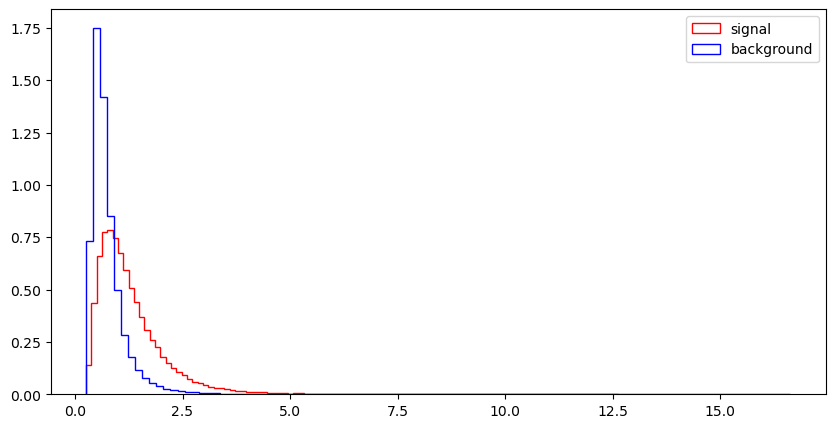

l_1_eta


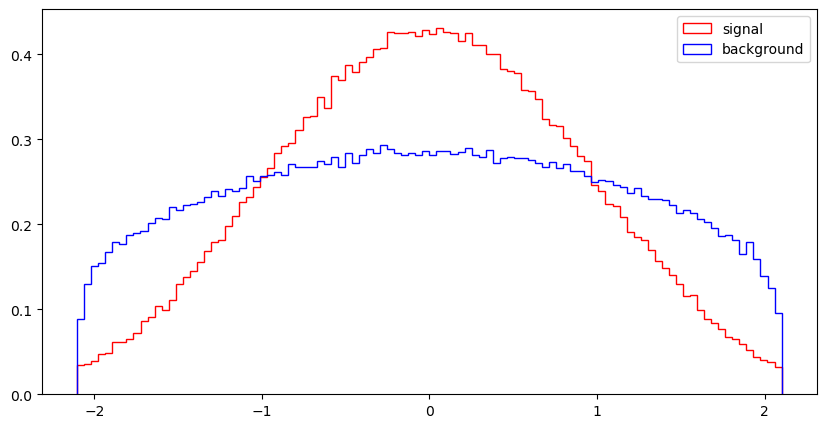

l_1_phi


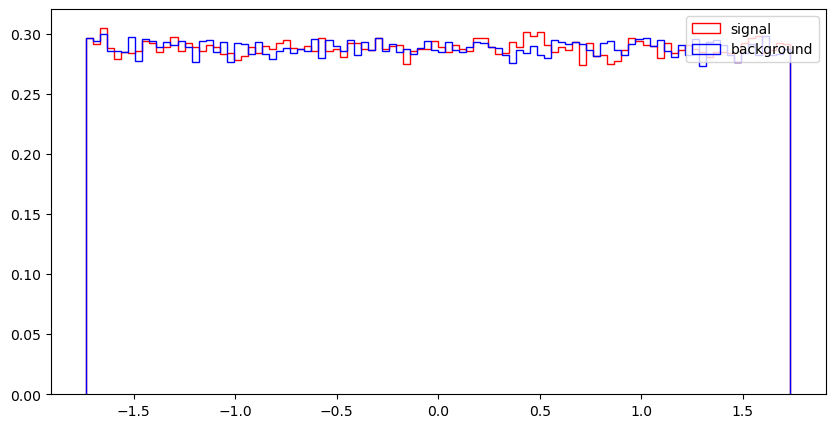

l_2_pT


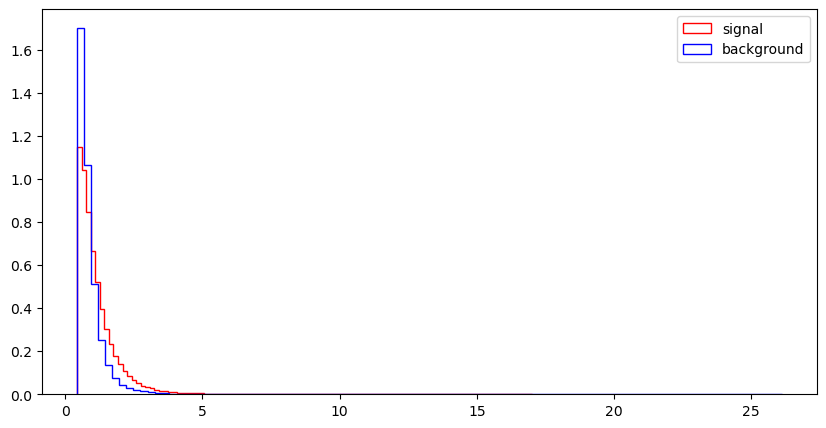

l_2_eta


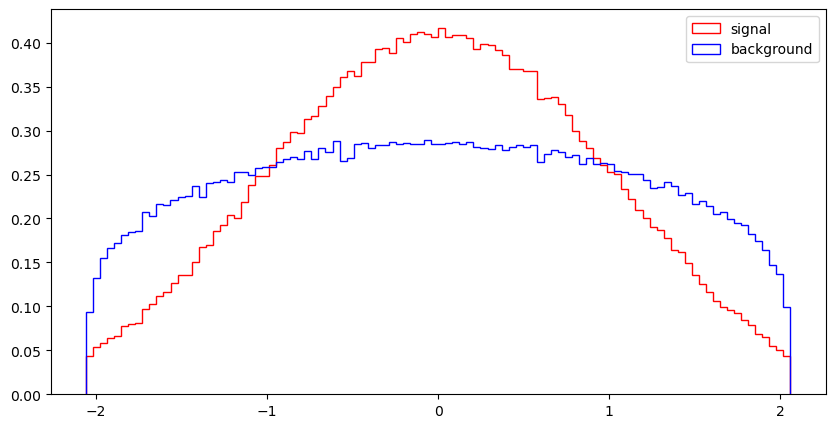

l_2_phi


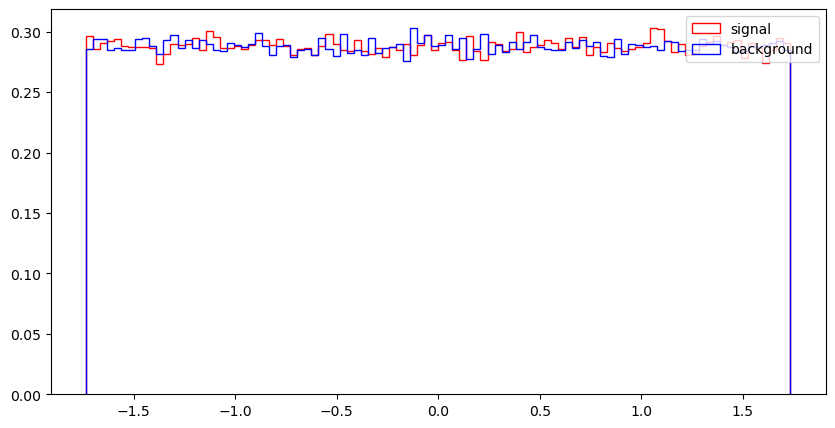

MET


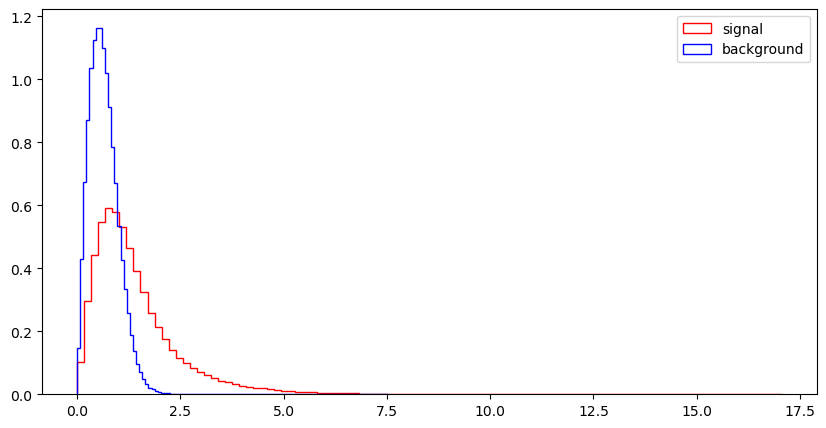

MET_phi


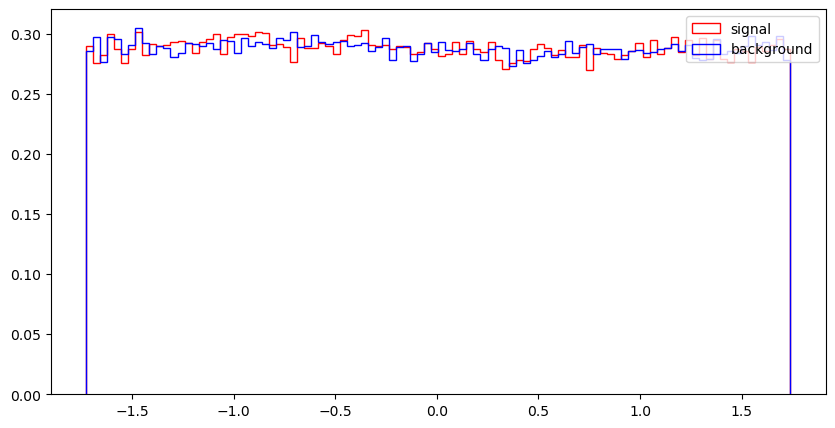

MET_rel


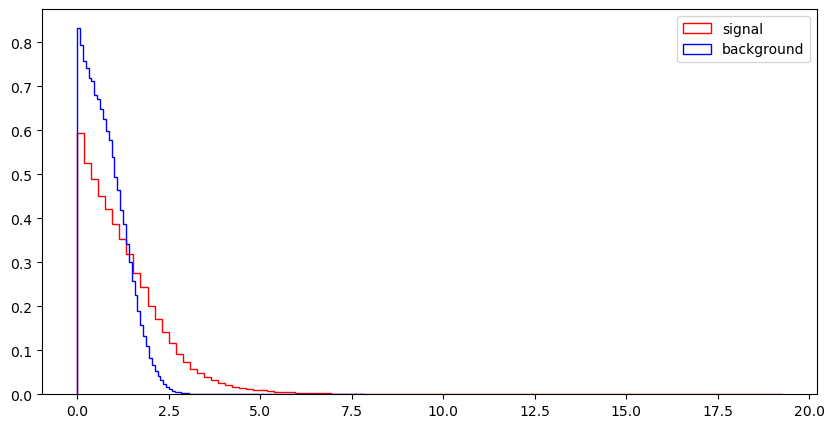

axial_MET


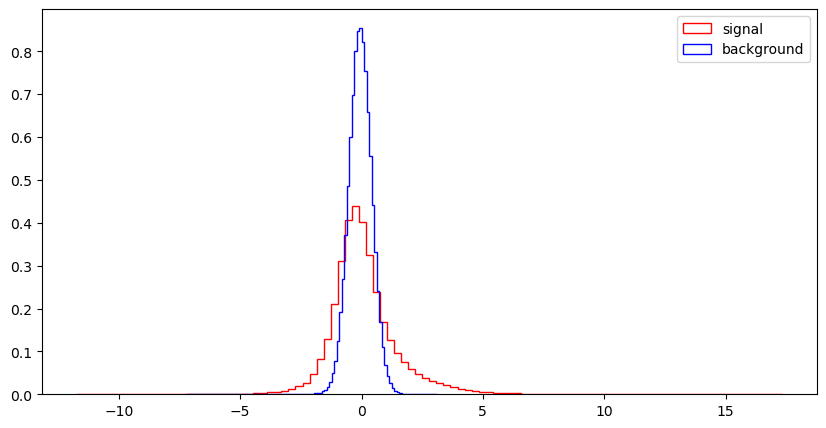

M_R


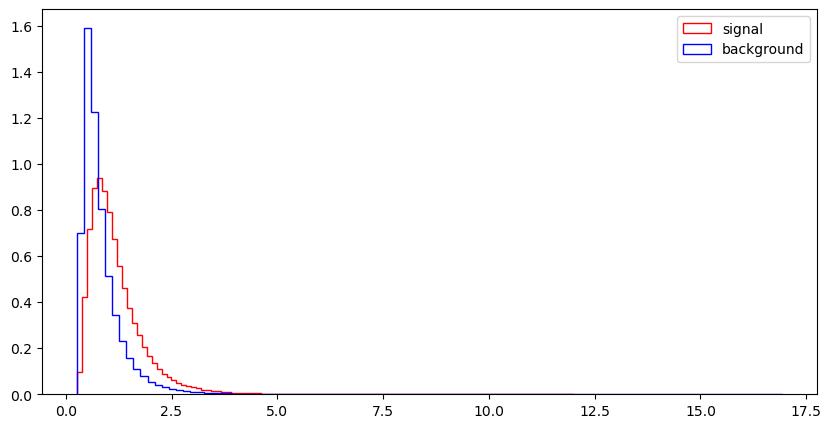

M_TR_2


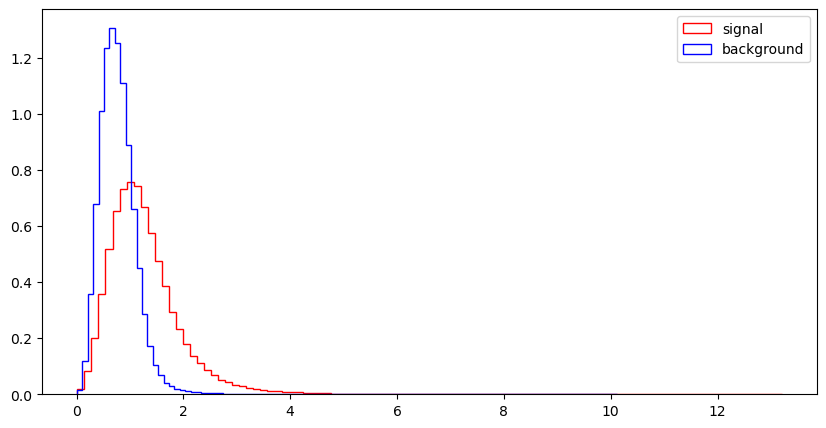

R


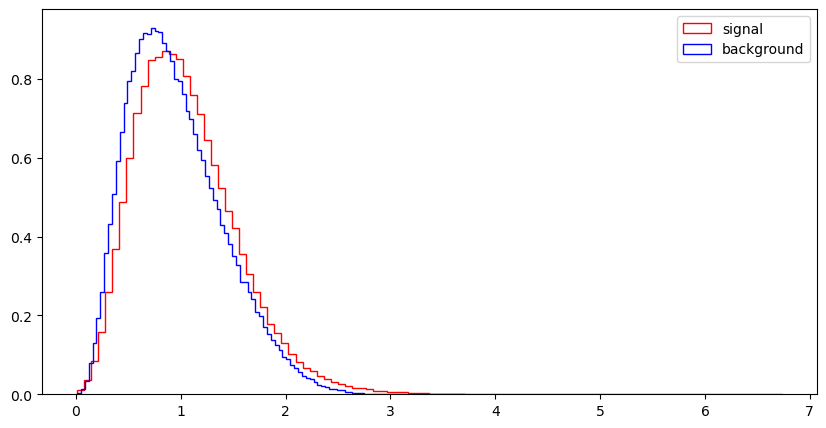

MT2


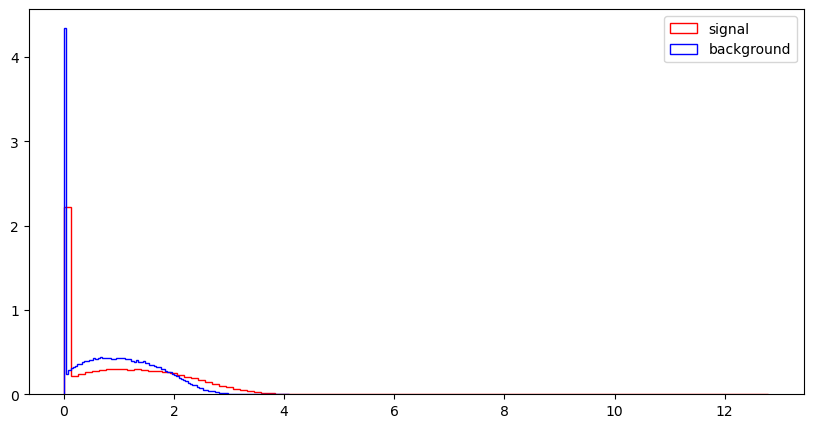

S_R


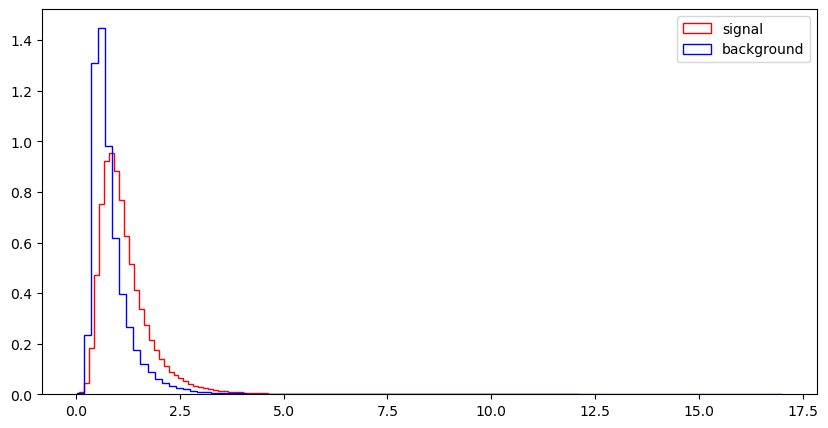

M_Delta_R


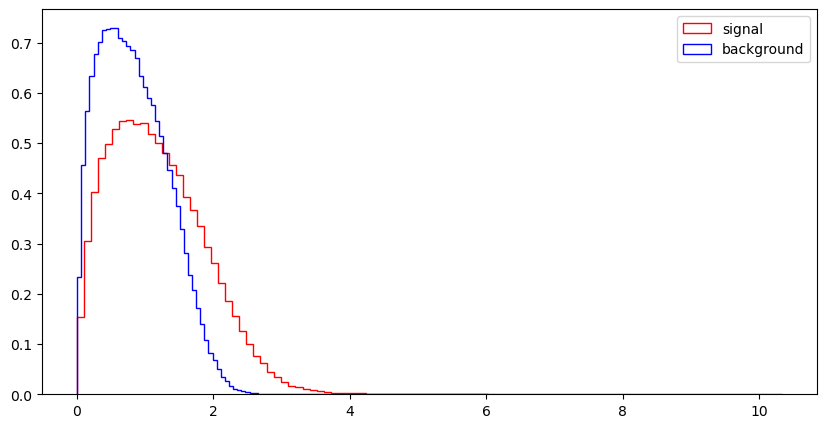

dPhi_r_b


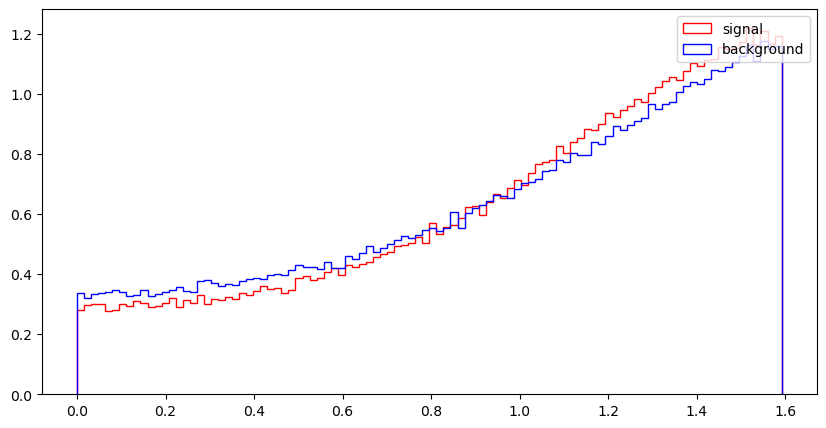

cos_theta_r1


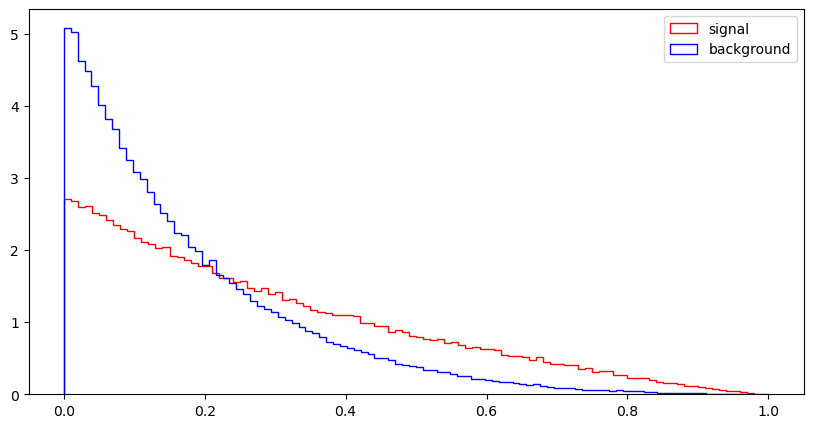

In [34]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [35]:
selection_dict={"Signal":df_sig,"Background":df_bkg}

In [36]:
def compare_distributions(selections, column_name, **kwargs):
    for label, selection in selections.items():
        _ = plt.hist(selection[column_name], label=label, **kwargs)  
    _ = plt.legend()

In [37]:
def compare_scatter(selections, x_var_name, y_var_name, make_legend=True):
    for label, selection in selections.items():
        _ = plt.scatter(selection[x_var_name], selection[y_var_name], label=label) 
    _ = plt.xlabel(x_var_name)
    _ = plt.ylabel(y_var_name)
    if make_legend:
        _ = plt.legend()


In [38]:
import matplotlib.pyplot as plt

def pair_plot_group(df, columns, selections, figsize=(15,15), bins=50, alpha=0.5, density=True):
    n_columns = len(columns)
    plt.figure(figsize=figsize)
    
    plot_i = 0
    for i, x_var_name in enumerate(columns):
        for j, y_var_name in enumerate(columns):
            plot_i += 1
            plt.subplot(n_columns, n_columns, plot_i)
            
            make_legend = (plot_i == 1)
            
            if i == j:
                for label, df_sel in selections.items():
                    plt.hist(df_sel[x_var_name], label=label, alpha=alpha, density=density, bins=bins)
                if make_legend:
                    plt.legend()
            else:
                for label, df_sel in selections.items():
                    plt.scatter(df_sel[x_var_name], df_sel[y_var_name], label=label)
                plt.xlabel(x_var_name)
                plt.ylabel(y_var_name)
                if make_legend:
                    plt.legend()

    plt.tight_layout()
    plt.show()


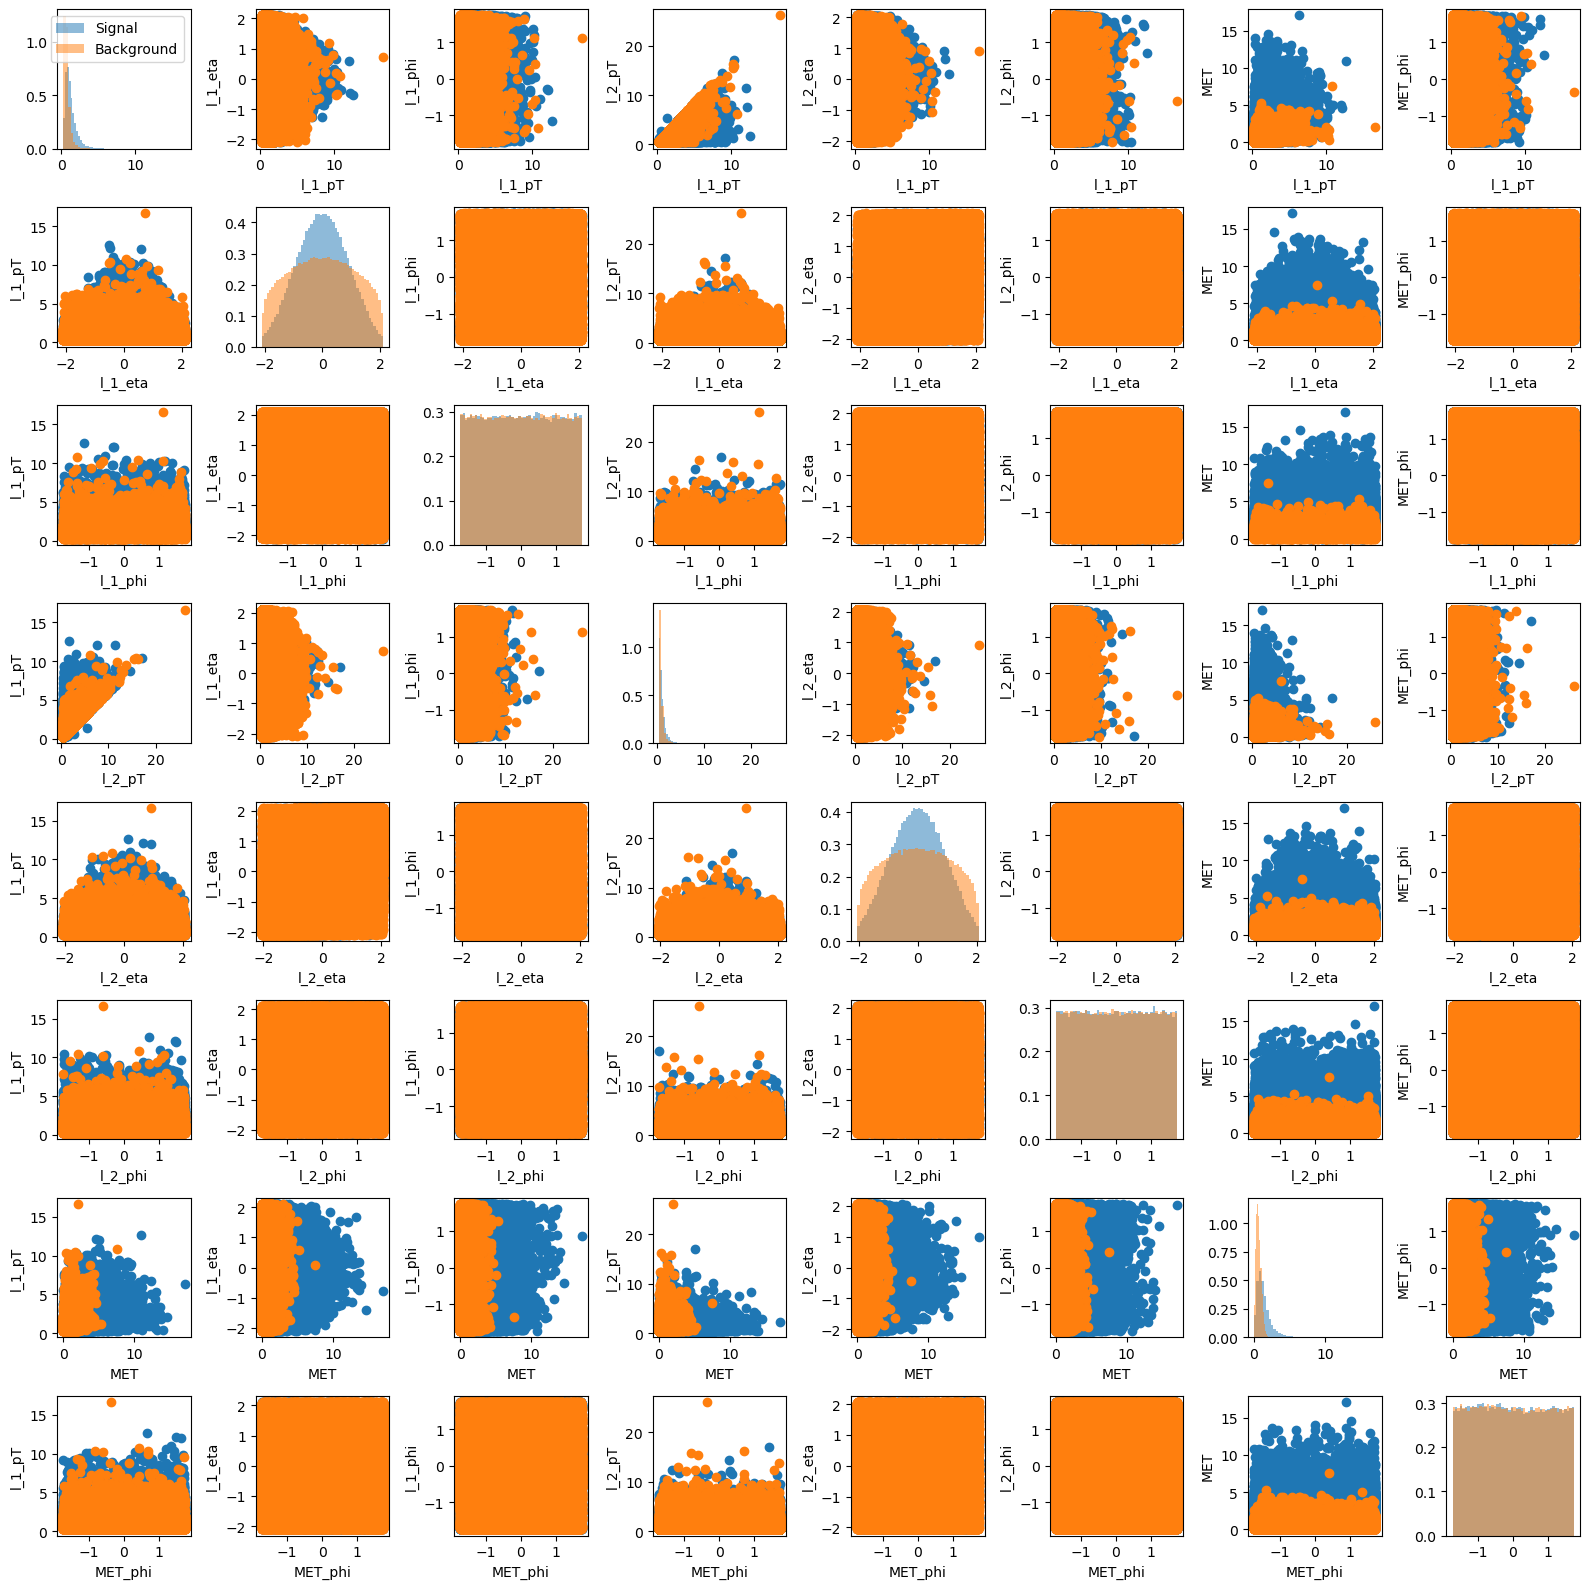

In [21]:
pair_plot_group(df, RawNames, selection_dict, figsize=(16,16))

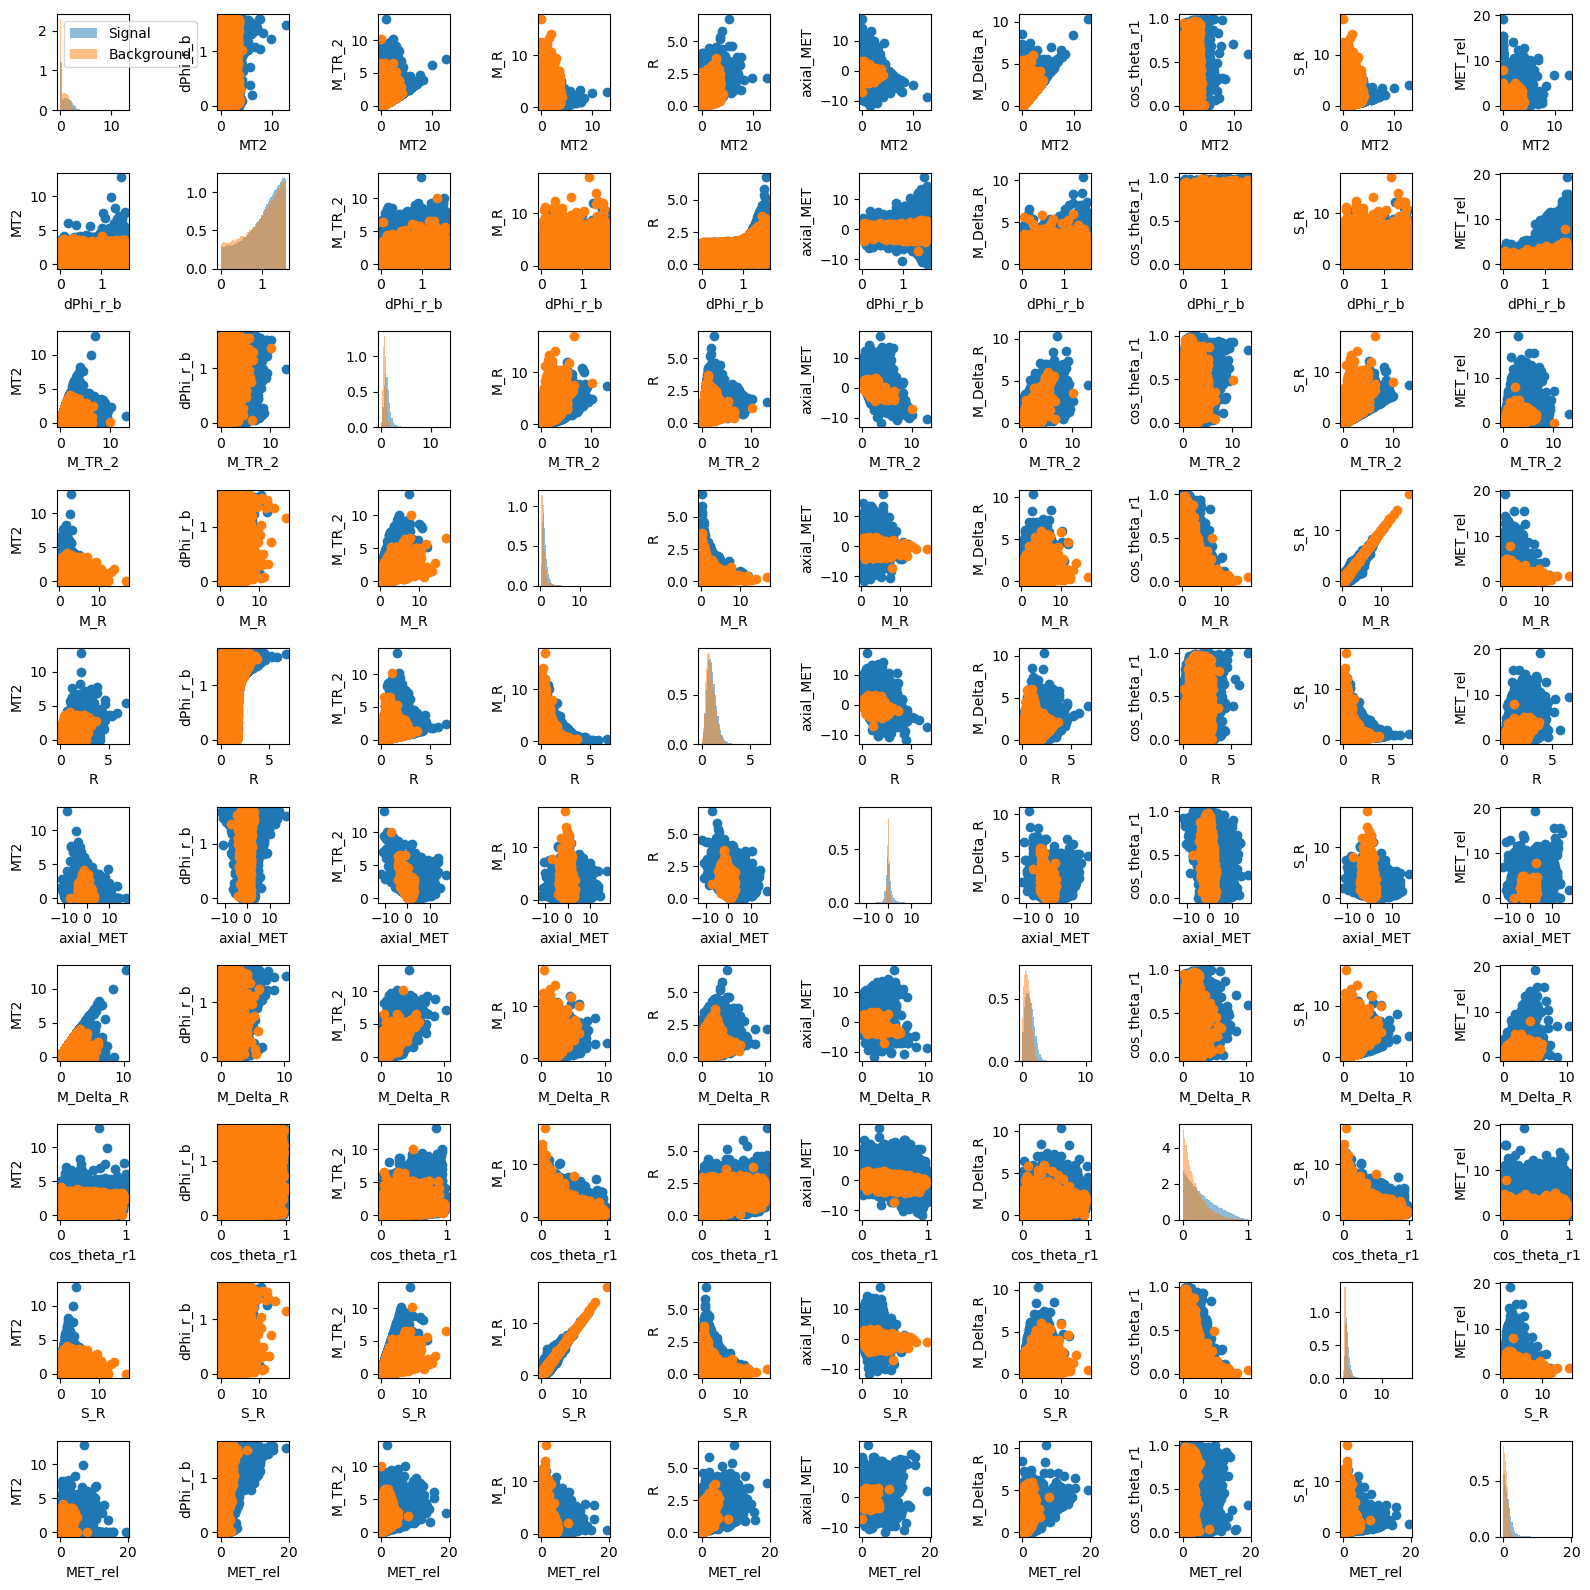

In [22]:
pair_plot_group(df, FeatureNames, selection_dict, figsize=(16,16))

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [39]:
from IPython.display import HTML, display
from tabulate import tabulate

In [40]:
##Covariance 
low_level_data = df[RawNames].values
high_level_data = df[FeatureNames].values

cov_low = np.cov(low_level_data, rowvar=False)  
cov_high = np.cov(high_level_data, rowvar=False)  

cov_low_df = pd.DataFrame(cov_low, index=RawNames, columns=RawNames)
cov_high_df = pd.DataFrame(cov_high, index=FeatureNames, columns=FeatureNames)

print("Covariance Matrix for Low-Level Features:")
print(cov_low_df)

print("\nCovariance Matrix for High-Level Features:")
print(cov_high_df)

Covariance Matrix for Low-Level Features:
           l_1_pT   l_1_eta   l_1_phi    l_2_pT   l_2_eta   l_2_phi       MET  \
l_1_pT   0.467482 -0.000397  0.000077  0.305038 -0.000349  0.000737  0.228434   
l_1_eta -0.000397  1.004301 -0.000858 -0.000163  0.408313 -0.001042 -0.002147   
l_1_phi  0.000077 -0.000858  1.003973  0.001313  0.000251 -0.266810  0.000766   
l_2_pT   0.305038 -0.000163  0.001313  0.425490 -0.000576  0.000156  0.079452   
l_2_eta -0.000349  0.408313  0.000251 -0.000576  1.006264  0.000442  0.000382   
l_2_phi  0.000737 -0.001042 -0.266810  0.000156  0.000442  1.003798 -0.000304   
MET      0.228434 -0.002147  0.000766  0.079452  0.000382 -0.000304  0.762249   
MET_phi -0.000937 -0.000589 -0.184804 -0.001562 -0.000322 -0.035434 -0.002792   

          MET_phi  
l_1_pT  -0.000937  
l_1_eta -0.000589  
l_1_phi -0.184804  
l_2_pT  -0.001562  
l_2_eta -0.000322  
l_2_phi -0.035434  
MET     -0.002792  
MET_phi  1.003313  

Covariance Matrix for High-Level Features:
    

In [41]:
##Correlation

corr_low = np.corrcoef(low_level_data, rowvar=False)
corr_high = np.corrcoef(high_level_data, rowvar=False)

corr_low_df = pd.DataFrame(corr_low, index=RawNames, columns=RawNames)
corr_high_df = pd.DataFrame(corr_high, index=FeatureNames, columns=FeatureNames)

print("Correlation Matrix for Low-Level Features:")
print(corr_low_df)

print("\nCorrelation Matrix for High-Level Features:")
print(corr_high_df)


Correlation Matrix for Low-Level Features:
           l_1_pT   l_1_eta   l_1_phi    l_2_pT   l_2_eta   l_2_phi       MET  \
l_1_pT   1.000000 -0.000579  0.000112  0.683954 -0.000509  0.001076  0.382675   
l_1_eta -0.000579  1.000000 -0.000854 -0.000249  0.406167 -0.001038 -0.002454   
l_1_phi  0.000112 -0.000854  1.000000  0.002009  0.000249 -0.265777  0.000876   
l_2_pT   0.683954 -0.000249  0.002009  1.000000 -0.000880  0.000239  0.139512   
l_2_eta -0.000509  0.406167  0.000249 -0.000880  1.000000  0.000439  0.000436   
l_2_phi  0.001076 -0.001038 -0.265777  0.000239  0.000439  1.000000 -0.000348   
MET      0.382675 -0.002454  0.000876  0.139512  0.000436 -0.000348  1.000000   
MET_phi -0.001368 -0.000587 -0.184133 -0.002390 -0.000321 -0.035309 -0.003193   

          MET_phi  
l_1_pT  -0.001368  
l_1_eta -0.000587  
l_1_phi -0.184133  
l_2_pT  -0.002390  
l_2_eta -0.000321  
l_2_phi -0.035309  
MET     -0.003193  
MET_phi  1.000000  

Correlation Matrix for High-Level Features:
  

In [42]:
def display_table(matrix, row_labels, col_labels, title="Matrix", precision=2):
    matrix_rounded = np.round(matrix, precision)
    
    table = [[row_labels[i]] + list(matrix_rounded[i]) for i in range(len(row_labels))]

    print(f"\n{title}\n")
    print(tabulate(table, headers=[""] + col_labels, tablefmt="plain"))

In [43]:
display_table(cov_low, RawNames, RawNames, title="Covariance Matrix (Low-Level Features)")
display_table(corr_low, RawNames, RawNames, title="Correlation Matrix (Low-Level Features)")


Covariance Matrix (Low-Level Features)

           l_1_pT    l_1_eta    l_1_phi    l_2_pT    l_2_eta    l_2_phi    MET    MET_phi
l_1_pT       0.47      -0          0         0.31      -0          0      0.23      -0
l_1_eta     -0          1         -0        -0          0.41      -0     -0         -0
l_1_phi      0         -0          1         0          0         -0.27   0         -0.18
l_2_pT       0.31      -0          0         0.43      -0          0      0.08      -0
l_2_eta     -0          0.41       0        -0          1.01       0      0         -0
l_2_phi      0         -0         -0.27      0          0          1     -0         -0.04
MET          0.23      -0          0         0.08       0         -0      0.76      -0
MET_phi     -0         -0         -0.18     -0         -0         -0.04  -0          1

Correlation Matrix (Low-Level Features)

           l_1_pT    l_1_eta    l_1_phi    l_2_pT    l_2_eta    l_2_phi    MET    MET_phi
l_1_pT       1         -0          

In [44]:
display_table(cov_high, FeatureNames, FeatureNames, title="Covariance Matrix (High-Level Features)")


Covariance Matrix (High-Level Features)

                dPhi_r_b    axial_MET    M_Delta_R    M_TR_2    MET_rel    MT2    cos_theta_r1    M_R      R    S_R
dPhi_r_b            0.19        -0.03         0.04      0.06       0.15   0.02            0.01  -0.03   0.09  -0
axial_MET          -0.03         1.01        -0.23     -0.19      -0.12  -0.46           -0.05   0.02  -0.18  -0.04
M_Delta_R           0.04        -0.23         0.39      0.24       0.41   0.43            0.04   0.07   0.17   0.1
M_TR_2              0.06        -0.19         0.24      0.34       0.3    0.19            0.05   0.21   0.1    0.23
MET_rel             0.15        -0.12         0.41      0.3        0.79   0.41            0.06   0.04   0.25   0.08
MT2                 0.02        -0.46         0.43      0.19       0.41   0.74            0.04  -0.04   0.23  -0.01
cos_theta_r1        0.01        -0.05         0.04      0.05       0.06   0.04            0.04  -0.01   0.06  -0.01
M_R                -0.03         0

In [45]:
display_table(corr_high, FeatureNames, FeatureNames, title="Correlation Matrix (High-Level Features)")


Correlation Matrix (High-Level Features)

                dPhi_r_b    axial_MET    M_Delta_R    M_TR_2    MET_rel    MT2    cos_theta_r1    M_R      R    S_R
dPhi_r_b            1           -0.06         0.16      0.23       0.38   0.06            0.11  -0.11   0.42  -0.01
axial_MET          -0.06         1           -0.37     -0.32      -0.13  -0.54           -0.27   0.03  -0.38  -0.07
M_Delta_R           0.16        -0.37         1         0.67       0.75   0.81            0.32   0.19   0.56   0.25
M_TR_2              0.23        -0.32         0.67      1          0.58   0.38            0.45   0.58   0.38   0.64
MET_rel             0.38        -0.13         0.75      0.58       1      0.54            0.32   0.08   0.59   0.15
MT2                 0.06        -0.54         0.81      0.38       0.54   1               0.26  -0.07   0.57  -0.02
cos_theta_r1        0.11        -0.27         0.32      0.45       0.32   0.26            1     -0.12   0.63  -0.09
M_R                -0.11     

## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [46]:
##5.1 - The best option overall is probably going to be x > x_c, because for each graph, there is more signal for higher values

In [47]:
##5.2 TPR/FPR

def compute_efficiencies(x_sig, x_bkg, cut_points):
    tpr = []
    fpr = []

    n_sig = len(x_sig)  
    n_bkg = len(x_bkg)  

    for x_c in cut_points:
        sig_pass = np.sum(x_sig > x_c)
        bkg_pass = np.sum(x_bkg > x_c)

        tpr_val = sig_pass / n_sig
        fpr_val = bkg_pass / n_bkg

        tpr.append(tpr_val)
        fpr.append(fpr_val)

    return np.array(tpr), np.array(fpr)

In [48]:
def plot_efficiencies_for_observable(x_sig, x_bkg, var_name, nbins=50):

    x_min = min(x_sig.min(), x_bkg.min())
    x_max = max(x_sig.max(), x_bkg.max())

    cut_points = np.linspace(x_min, x_max, nbins)

    tpr, fpr = compute_efficiencies(x_sig, x_bkg, cut_points)

    plt.figure(figsize=(8, 6))
    plt.plot(cut_points, tpr, label="Signal Efficiency (TPR)")
    plt.plot(cut_points, fpr, label="Background Efficiency (FPR)")
    plt.xlabel(f"{var_name} (cut value)")
    plt.ylabel("Efficiency")
    plt.title(f"TPR and FPR vs. Cut for {var_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


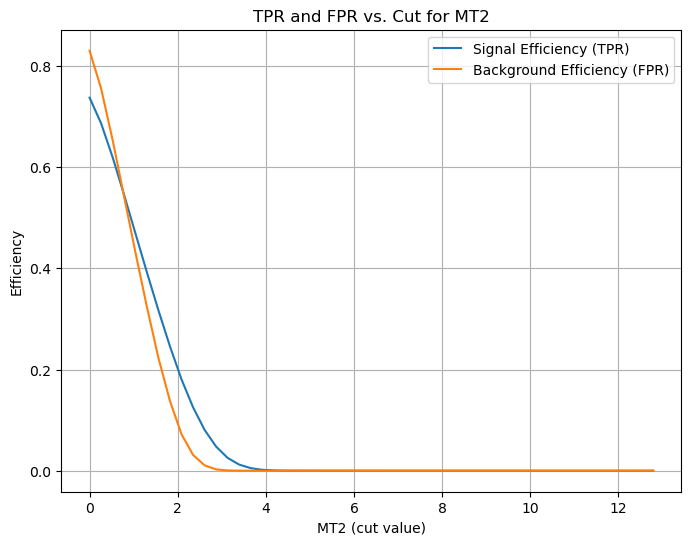

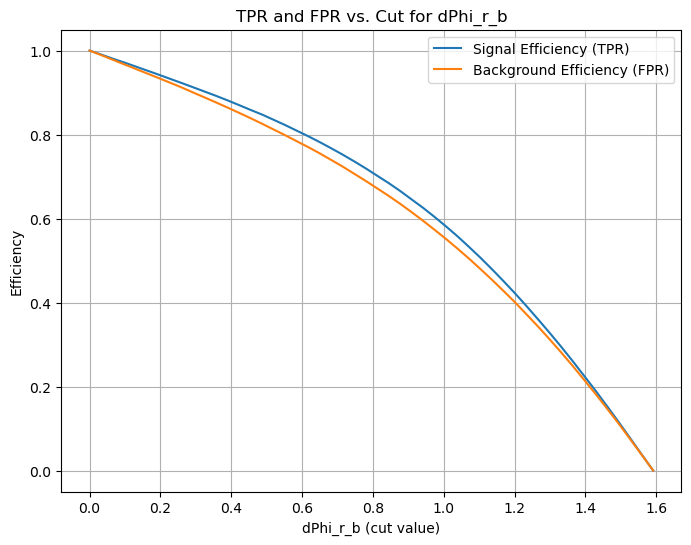

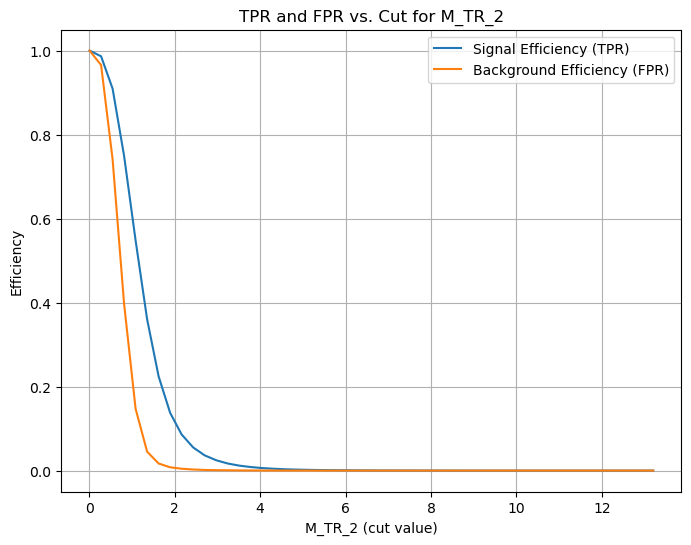

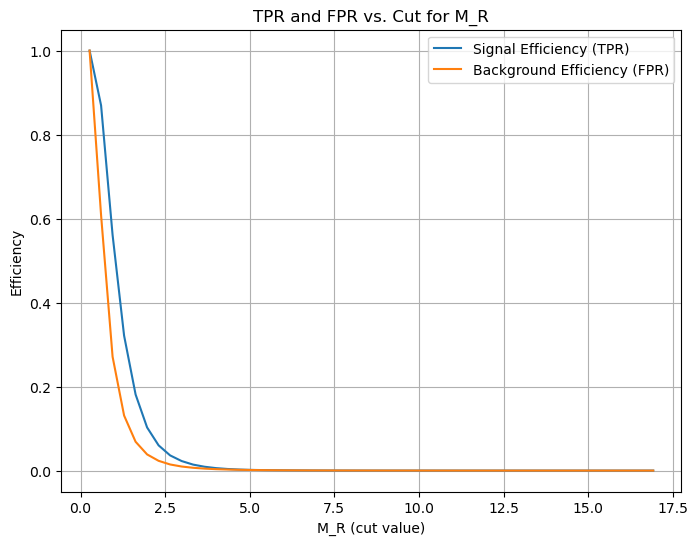

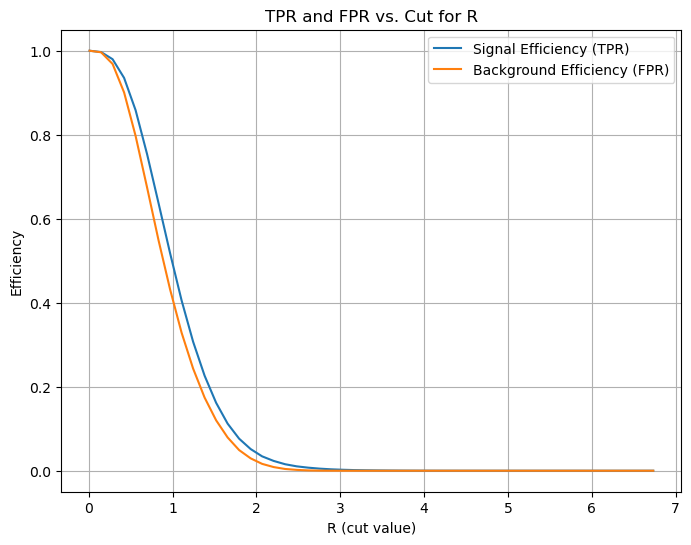

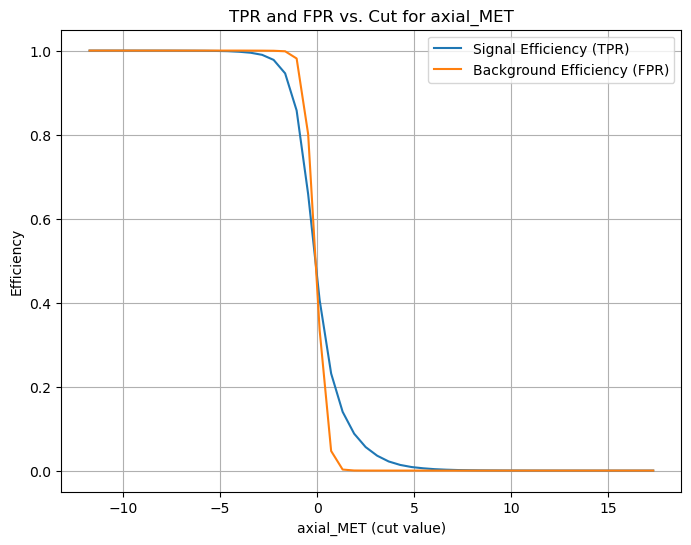

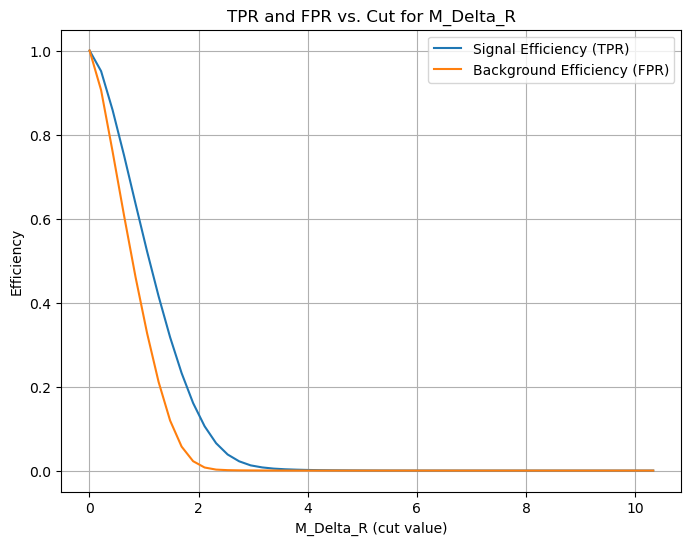

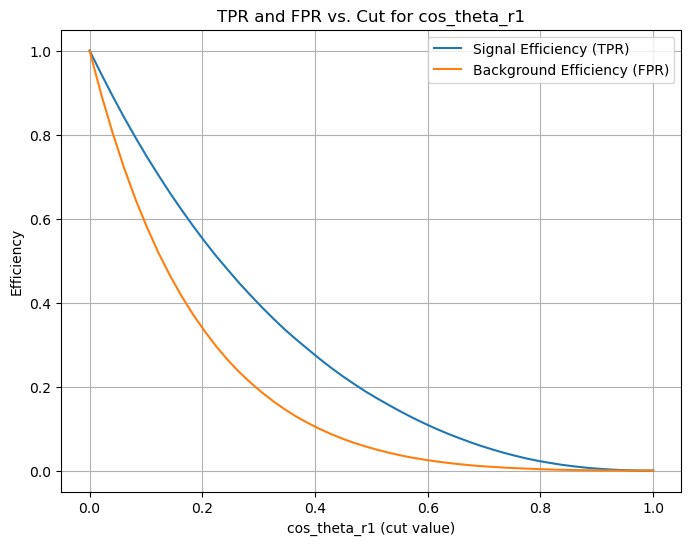

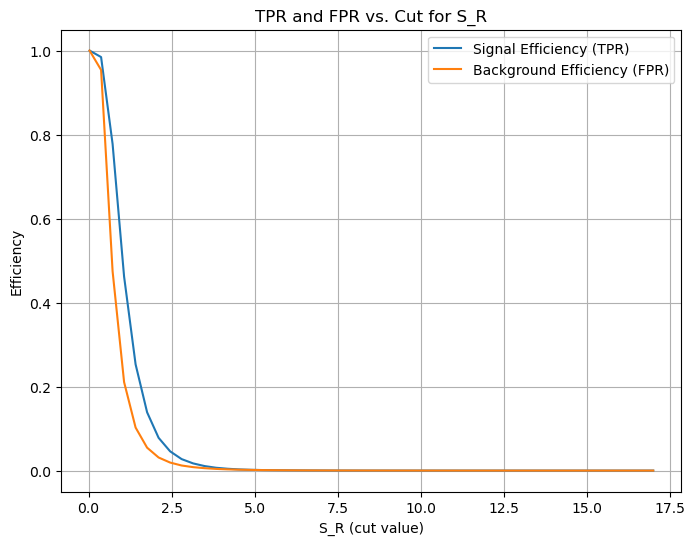

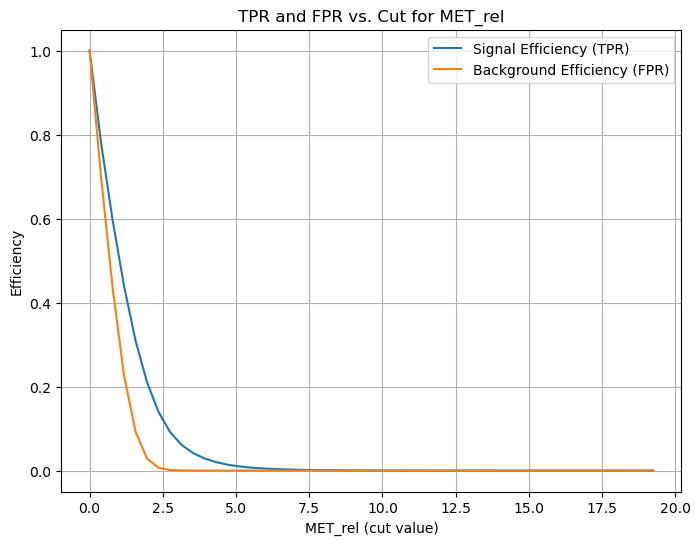

In [25]:
for var_name in FeatureNames:
    x_sig = df_sig[var_name].values
    x_bkg = df_bkg[var_name].values
    plot_efficiencies_for_observable(x_sig, x_bkg, var_name, nbins=50)

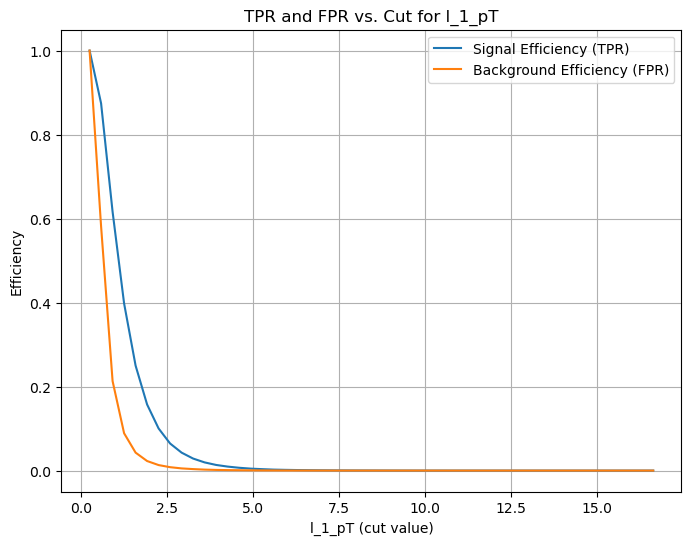

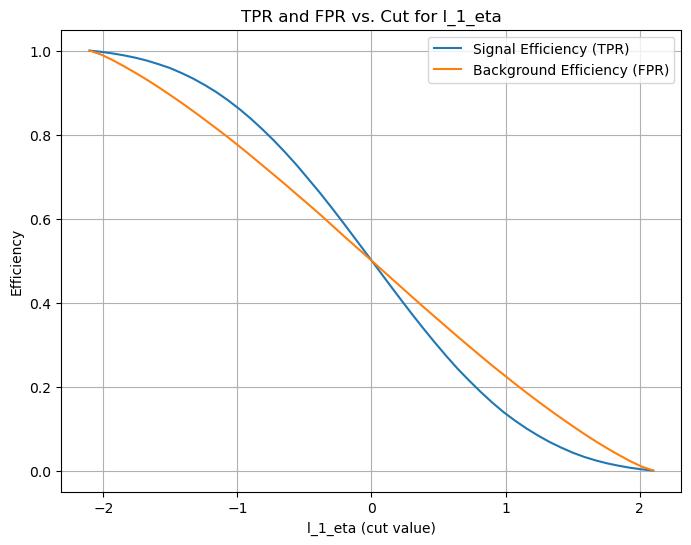

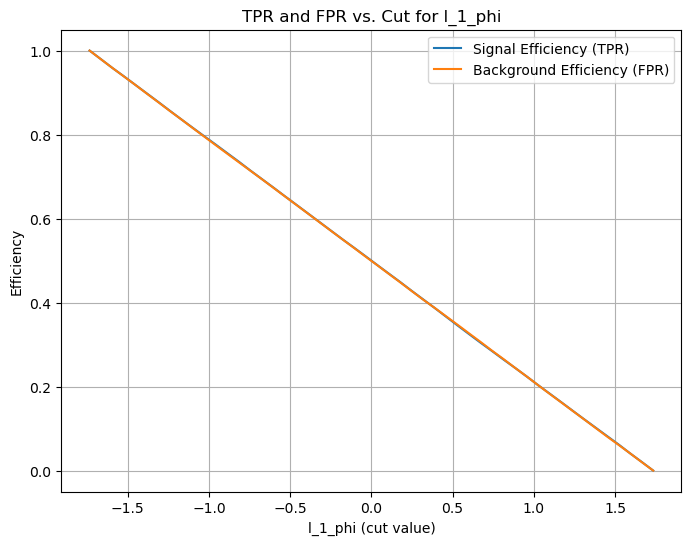

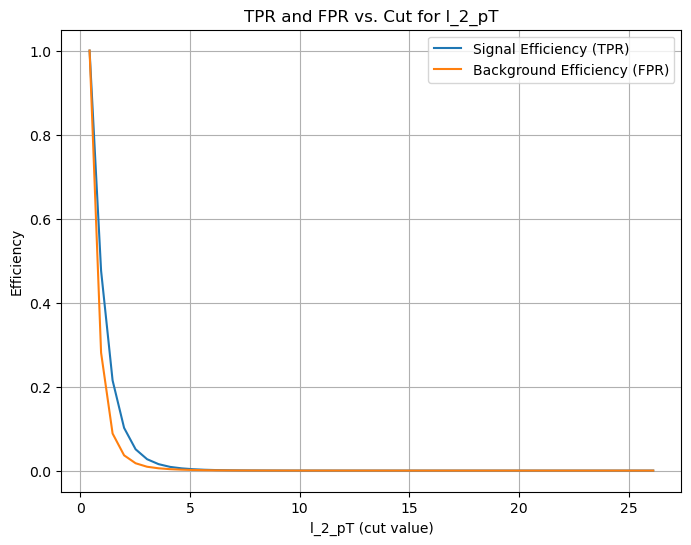

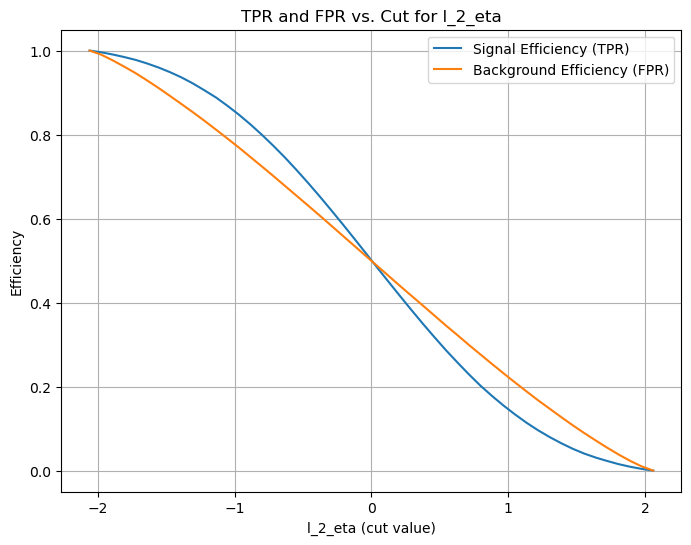

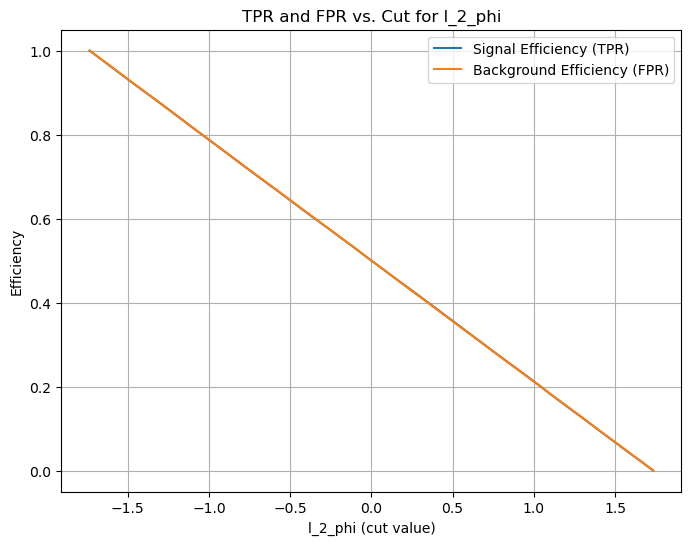

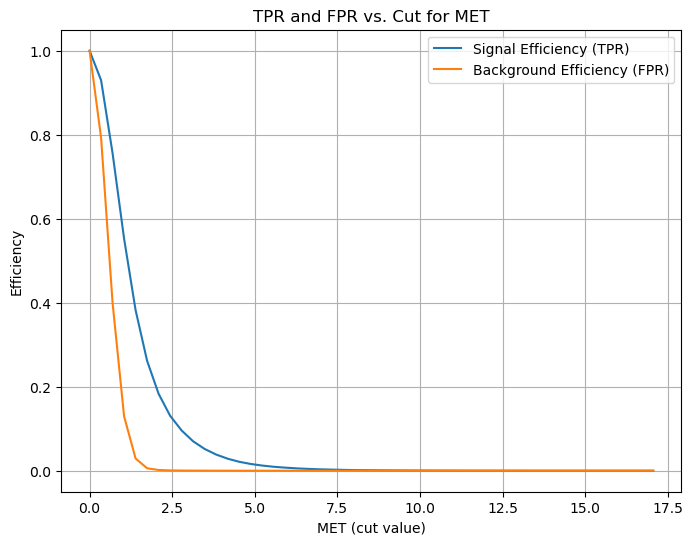

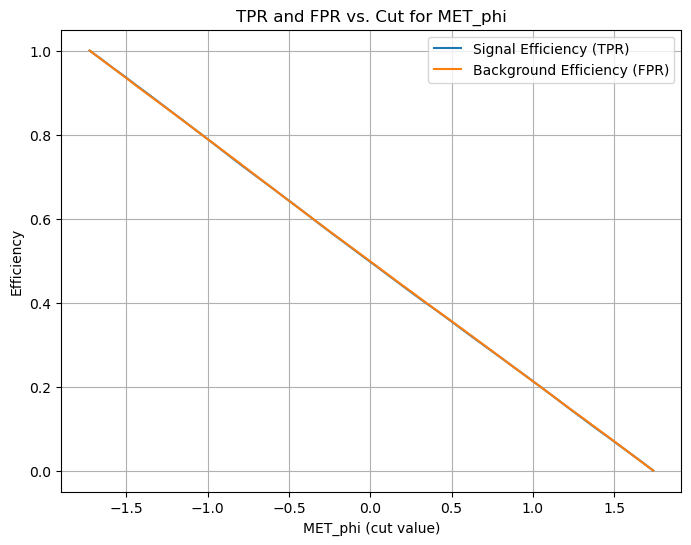

In [26]:
for var_name in RawNames:
    x_sig = df_sig[var_name].values
    x_bkg = df_bkg[var_name].values
    plot_efficiencies_for_observable(x_sig, x_bkg, var_name, nbins=50)

In [49]:
def compute_significance(tpr, fpr, N_S, N_B):
    N_S_prime = tpr * N_S
    N_B_prime = fpr * N_B
    significance = N_S_prime / np.sqrt(N_S_prime + N_B_prime)
    return significance

def plot_significance(x_sig, x_bkg, var_name, scenarios, nbins=50):
    x_min = min(x_sig.min(), x_bkg.min())
    x_max = max(x_sig.max(), x_bkg.max())

    cut_points = np.linspace(x_min, x_max, nbins)

    tpr, fpr = compute_efficiencies(x_sig, x_bkg, cut_points)

    plt.figure(figsize=(8, 6))
    
    for (N_S, N_B) in scenarios:
        significance = compute_significance(tpr, fpr, N_S, N_B)
        plt.plot(cut_points, significance, label=f"N_S={N_S}, N_B={N_B}")

    plt.xlabel(f"{var_name} (cut value)")
    plt.ylabel("Significance (σ_S')")
    plt.title(f"Significance vs. Cut for {var_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [50]:
Scenarios = [(10, 100), (100, 1000), (1000, 10000), (10000, 100000)]

/tmp/ipykernel_475/4293859149.py:4: RuntimeWarning: invalid value encountered in divide
  significance = N_S_prime / np.sqrt(N_S_prime + N_B_prime)


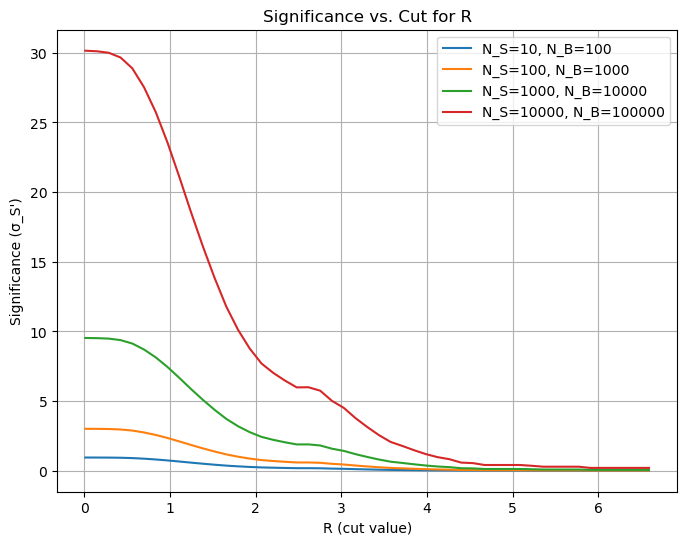

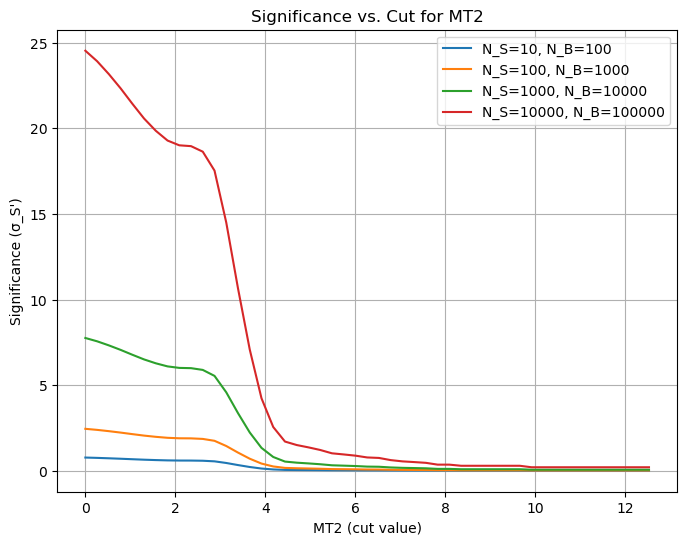

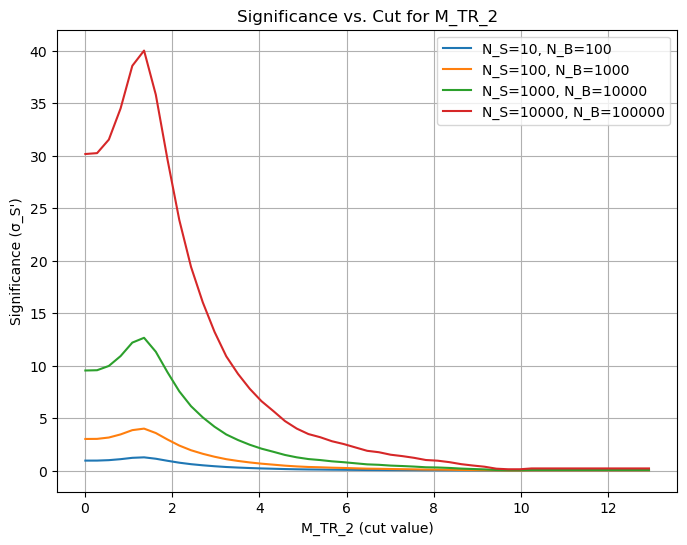

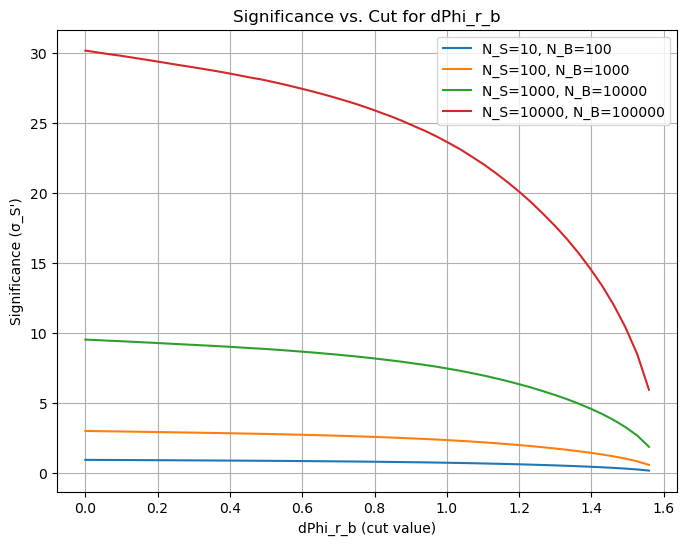

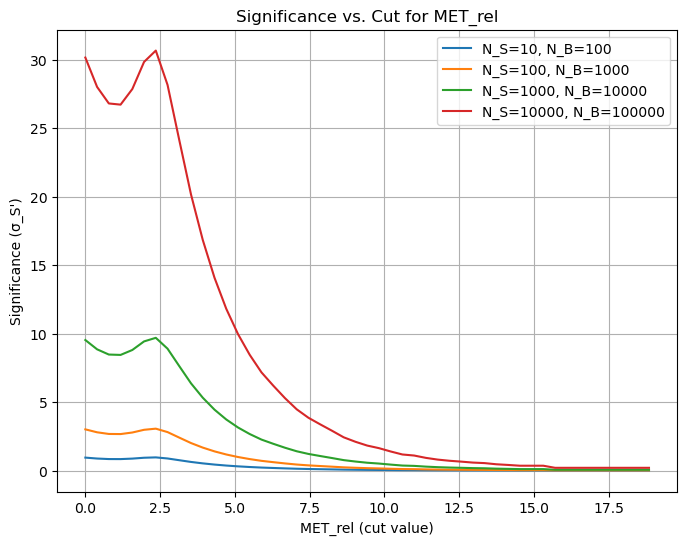

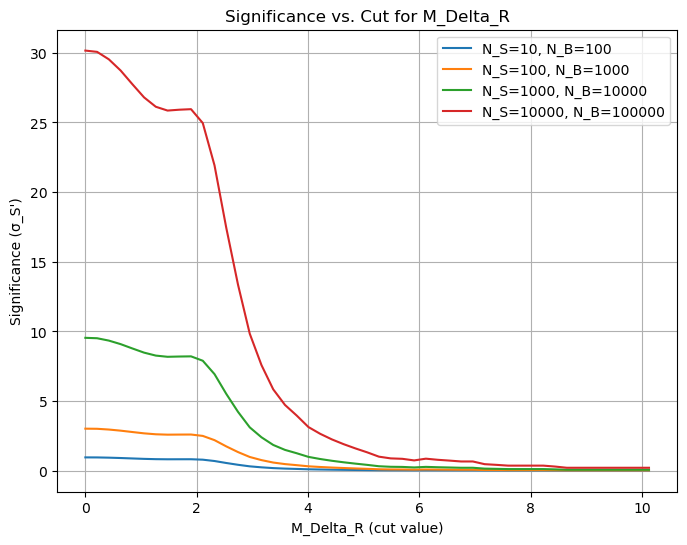

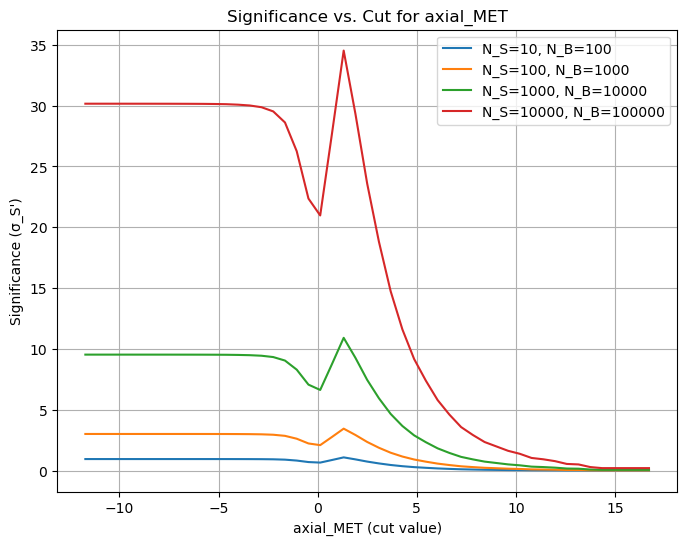

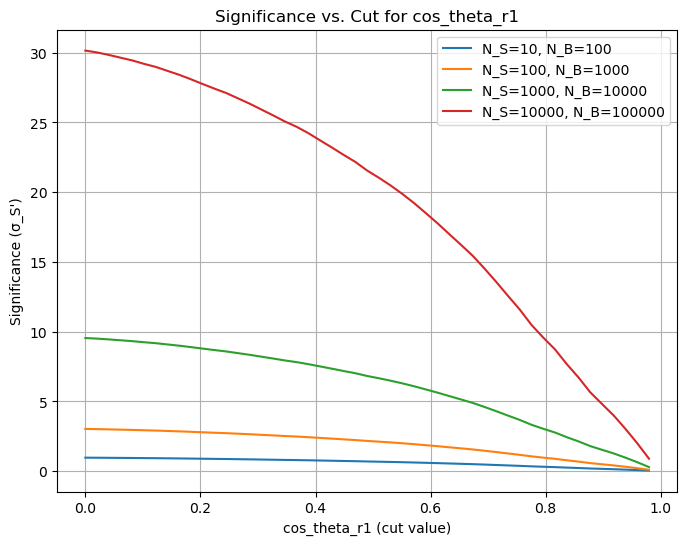

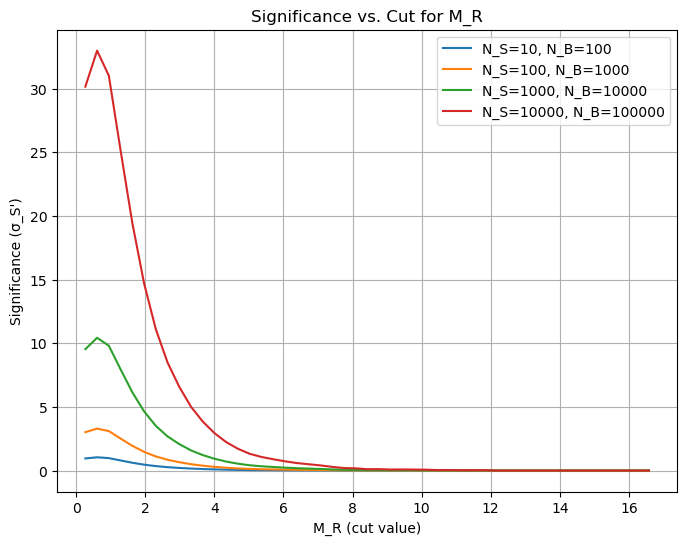

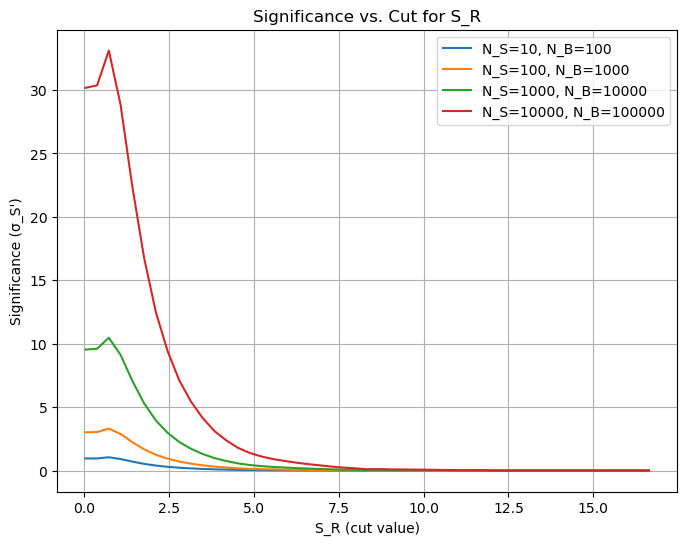

In [28]:
for var_name in FeatureNames:
    x_sig = df_sig[var_name].values
    x_bkg = df_bkg[var_name].values
    plot_significance(x_sig, x_bkg, var_name, Scenarios)

/tmp/ipykernel_475/4293859149.py:4: RuntimeWarning: invalid value encountered in divide
  significance = N_S_prime / np.sqrt(N_S_prime + N_B_prime)


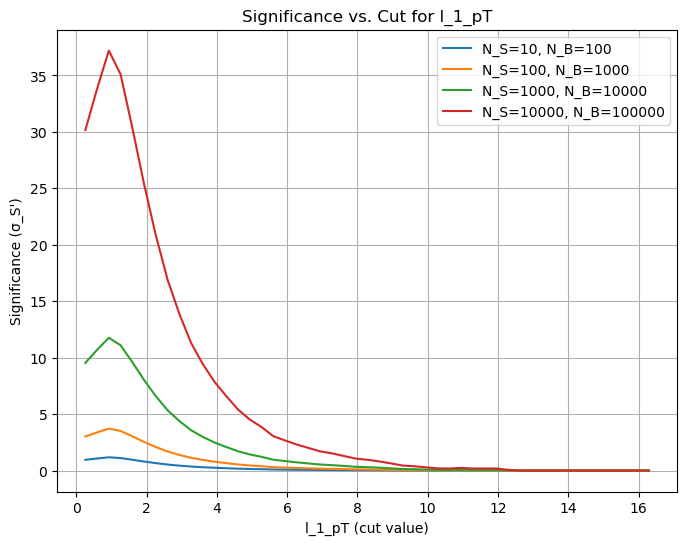

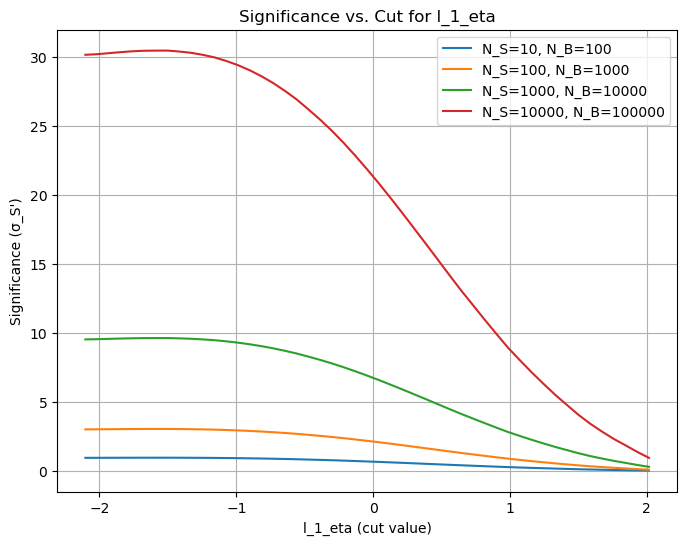

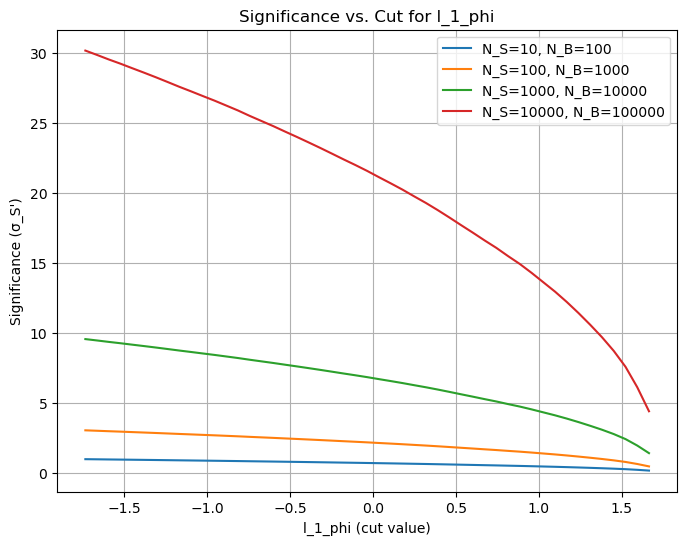

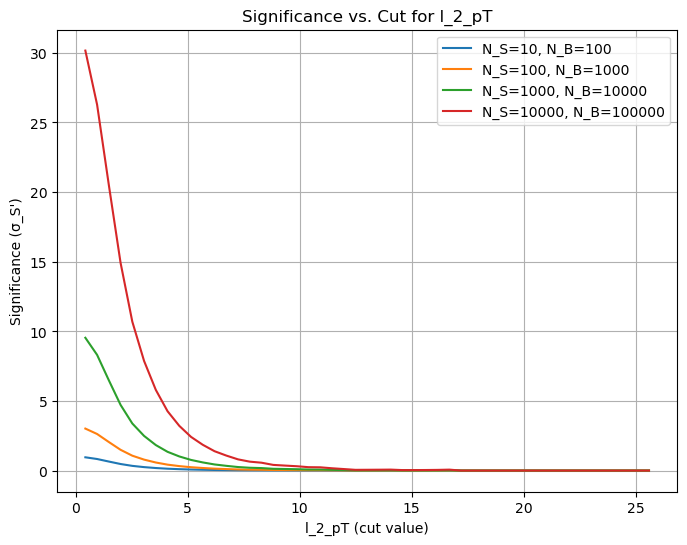

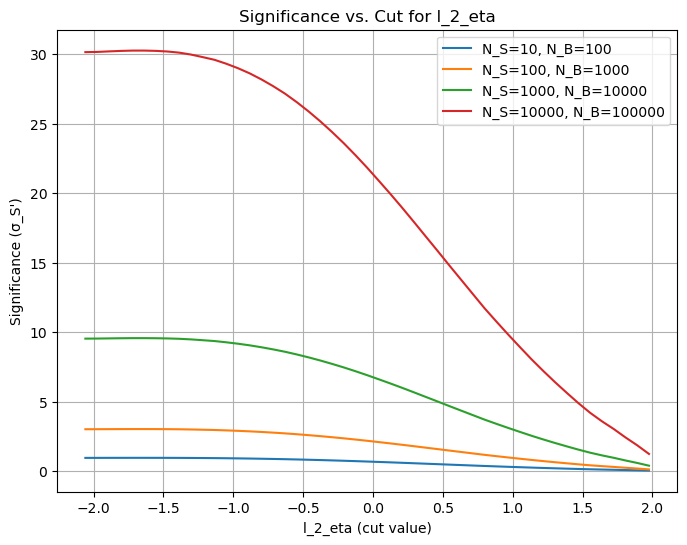

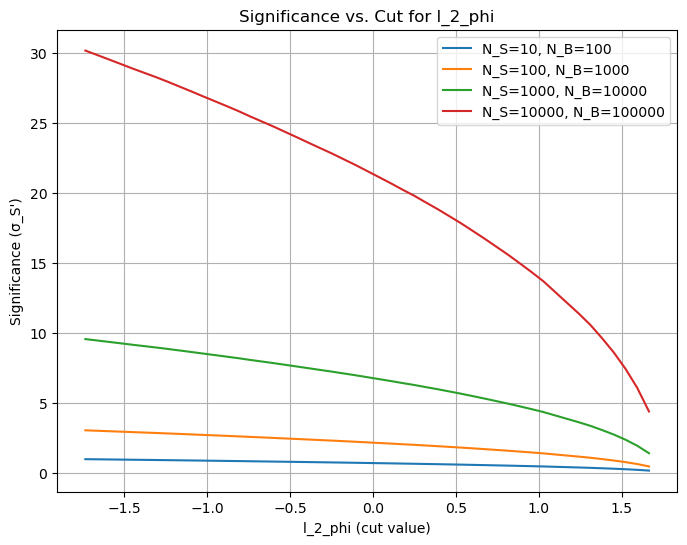

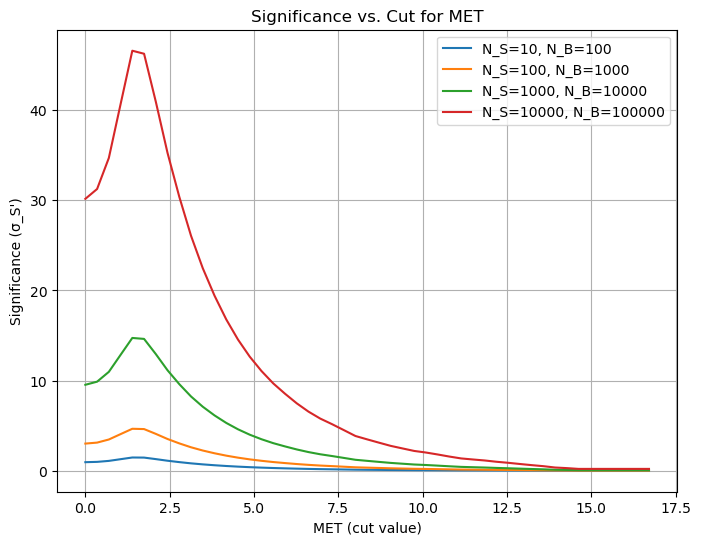

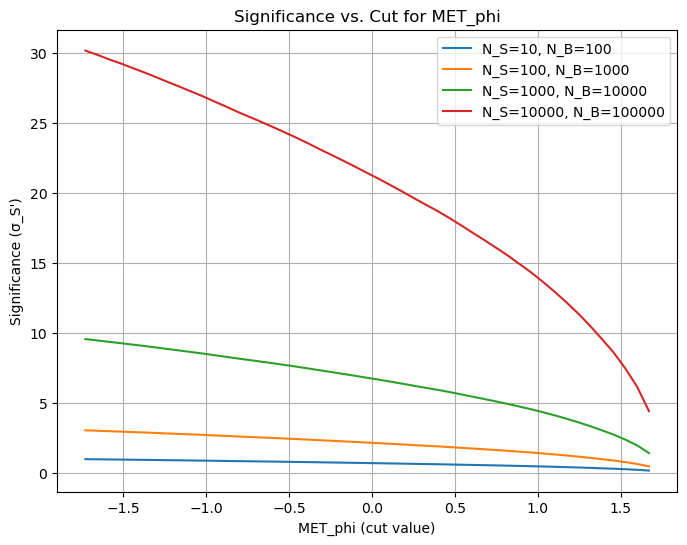

In [29]:
for var_name in RawNames:
    x_sig = df_sig[var_name].values
    x_bkg = df_bkg[var_name].values
    plot_significance(x_sig, x_bkg, var_name, Scenarios)

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [51]:
## axial_MET(at 1.25), M_R(at 0.5), S_R(at 1)

def generate_cut_flow_table(df_sig, df_bkg, feature_names, cut_values, scenarios):
    table_data = []
    
    for feature, x_c in zip(feature_names, cut_values):
        x_sig = df_sig[feature].values
        x_bkg = df_bkg[feature].values
        
        tpr, fpr = compute_efficiencies(x_sig, x_bkg, [x_c])
        
        for N_S, N_B in scenarios:
            significance = compute_significance(tpr, fpr, N_S, N_B)
            table_data.append([feature, x_c, tpr[0], fpr[0], tpr[0]*N_S, fpr[0]*N_B, significance[0]])
    
    headers = ["Observable", "Cut Value", "𝜖_S (TPR)", "𝜖_B (FPR)", "N'_S", "N'_B", "σ_S'"]
    print(tabulate(table_data, headers=headers, floatfmt=".4f", tablefmt="grid"))

def generate_range_tables(df_sig, df_bkg, feature, x_range, scenarios):
    table_data = []
    
    x_sig = df_sig[feature].values
    x_bkg = df_bkg[feature].values
    tpr, fpr = compute_efficiencies(x_sig, x_bkg, x_range)
    
    for i, x_c in enumerate(x_range):
        for N_S, N_B in scenarios:
            significance = compute_significance([tpr[i]], [fpr[i]], N_S, N_B)
            table_data.append([x_c, tpr[i], fpr[i], tpr[i]*N_S, fpr[i]*N_B, significance[0]])
    
    headers = ["Cut Value", "𝜖_S (TPR)", "𝜖_B (FPR)", "N'_S", "N'_B", "σ_S'"]
    print(f"\nSignificance Table for {feature}")
    print(tabulate(table_data, headers=headers, floatfmt=".4f", tablefmt="grid"))



In [52]:
generate_cut_flow_table(df_sig, df_bkg, ["M_R", "S_R", "axial_MET"], [0.5, 1.0, 1.25], [(1000, 10000), (100, 1000)])

+--------------+-------------+-------------+-------------+----------+-----------+---------+
| Observable   |   Cut Value |   𝜖_S (TPR) |   𝜖_B (FPR) |     N'_S |      N'_B |    σ_S' |
+==============+=============+=============+=============+==========+===========+=========+
| M_R          |      0.5000 |      0.9432 |      0.7764 | 943.2354 | 7764.4365 | 10.1081 |
+--------------+-------------+-------------+-------------+----------+-----------+---------+
| M_R          |      0.5000 |      0.9432 |      0.7764 |  94.3235 |  776.4436 |  3.1965 |
+--------------+-------------+-------------+-------------+----------+-----------+---------+
| S_R          |      1.0000 |      0.5163 |      0.2436 | 516.3384 | 2436.3724 |  9.5022 |
+--------------+-------------+-------------+-------------+----------+-----------+---------+
| S_R          |      1.0000 |      0.5163 |      0.2436 |  51.6338 |  243.6372 |  3.0049 |
+--------------+-------------+-------------+-------------+----------+-----------

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 